In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def analyze_svr_tuned(data, layer, plot_tuning=True):

    feature_cols = [
        'mu', 'sigma',
        'feat_0','feat_1','feat_2','feat_3','feat_4','feat_5',
        'feat_6','feat_7','feat_8','feat_9','feat_10','feat_11',
        'feat_12','feat_13','feat_14','feat_15',
        'Bandstop Frequency', 'Bandstop Magnitude', 'BW',
        # 'Phase_1GHz_deg', 'Phase_2GHz_deg',
        'Slope',
        'Age','Gender','Height[m]','Weight[kg]','BMI',
        'device'
    ]

    X = data[feature_cols].copy()
    X['Gender'] = X['Gender'].map({'M': 1, 'F': 0})
    X['device'] = X['device'].map({
        'CopperMountain': 0,
        'nanoVNA': 1,
        'NEW protocol': 1
    })

    if layer == 'muscle':
        y = data['Rfcsa[cm2]']
    elif layer == 'skin':
        y = data['Skin[mm]']
    elif layer == 'fat':
        y = data['Fat[mm]']
    else:
        raise ValueError("layer must be muscle, skin, or fat")

    df = X.copy()
    df['target'] = y
    df['group'] = data['volunteer']
    df = df.dropna()

    X = df[feature_cols]
    y = df['target']
    groups = df['group']

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ])

    param_grid = {
        'svr__kernel': ['rbf'],
        'svr__C': [0.1, 1, 10, 50, 100],
        'svr__epsilon': [0.001, 0.01, 0.05, 0.1, 0.2],
        'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    }

    cv = GroupKFold(n_splits=5)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )

    grid.fit(X_train, y_train, groups=groups_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results = pd.DataFrame(grid.cv_results_)
    results['mean_val_mae'] = -results['mean_test_score']
    results['std_val_mae'] = results['std_test_score']
    results['mean_train_mae'] = -results['mean_train_score']
    results = results.sort_values('mean_val_mae').reset_index(drop=True)

    if plot_tuning:
        plt.figure(figsize=(12, 5))
        plt.plot(
            results.index,
            results['mean_val_mae'],
            marker='o',
            label='Validation MAE'
        )
        plt.plot(
            results.index,
            results['mean_train_mae'],
            marker='o',
            label='Training MAE'
        )
        plt.fill_between(
            results.index,
            results['mean_val_mae'] - results['std_val_mae'],
            results['mean_val_mae'] + results['std_val_mae'],
            alpha=0.2
        )

        plt.xlabel("Hyperparameter Combination Rank")
        plt.ylabel("MAE")
        plt.title(f"SVR Hyperparameter Tuning Curve - {layer}")
        plt.legend()
        plt.grid(True)
        plt.show()

    print("Best parameters:", grid.best_params_)
    print("Best CV MAE:", -grid.best_score_)
    print("Test MAE:", mae)
    print("Test R2:", r2)

    return best_model, grid.best_params_, results, X_test, y_test, y_pred, mae, r2

In [3]:
from sklearn.metrics.pairwise import kernel_metrics
def analyze(data, layer, params=None,model=None):
    feature_cols = [
        'mu', 'sigma',

        'feat_0','feat_1','feat_2','feat_3','feat_4','feat_5',
        'feat_6','feat_7','feat_8','feat_9','feat_10','feat_11',
        'feat_12','feat_13','feat_14','feat_15',

        'Bandstop Frequency',
        'Bandstop Magnitude',
        'BW',
        'Phase_1GHz_deg',
        'Phase_2GHz_deg',
        'Slope',

        'Age','Gender','Height[m]','Weight[kg]','BMI',

        'device'
    ]

    X = data[feature_cols].copy()

    X['Gender'] = X['Gender'].map({'M': 1, 'F': 0})
    X['device'] = X['device'].map({
        'CopperMountain': 0,
        'nanoVNA': 1,
        'NEW protocol': 1
    })

    if layer == 'muscle':
        y = data['Rfcsa[cm2]']
    elif layer == 'skin':
        y = data['Skin[mm]']
    elif layer == 'fat':
        y = data['Fat[mm]']
    else:
        raise ValueError("layer must be one of: muscle, skin, fat")

    # keep groups aligned before dropping rows
    groups = data['volunteer']

    df = X.copy()
    df['target'] = y
    df['group'] = groups

    df = df.dropna()

    X = df[feature_cols]
    y = df['target']
    groups = df['group']

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    #Best parameters:
    if params is None:
      c, epsilon, gamma, kernel = 10, 0.01, 'scale', 'rbf'
    else:
      c, epsilon, gamma, kernel = params['svr__C'], params['svr__epsilon'], params['svr__gamma'], params['svr__kernel']
    if model is None:
      model = Pipeline([
          ('scaler', StandardScaler()),
           ('svr', SVR(kernel=kernel, C=c, epsilon=epsilon))
           ])
    else:
      model = model

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return model, X_test, y_test, y_pred, mae, r2

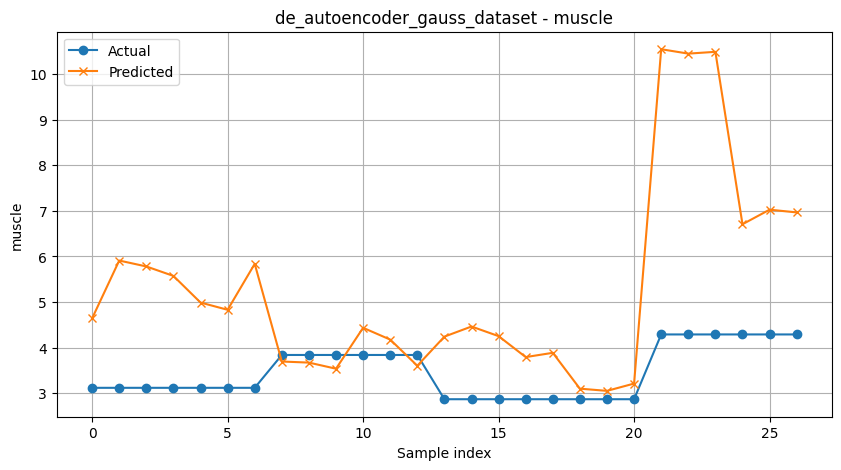

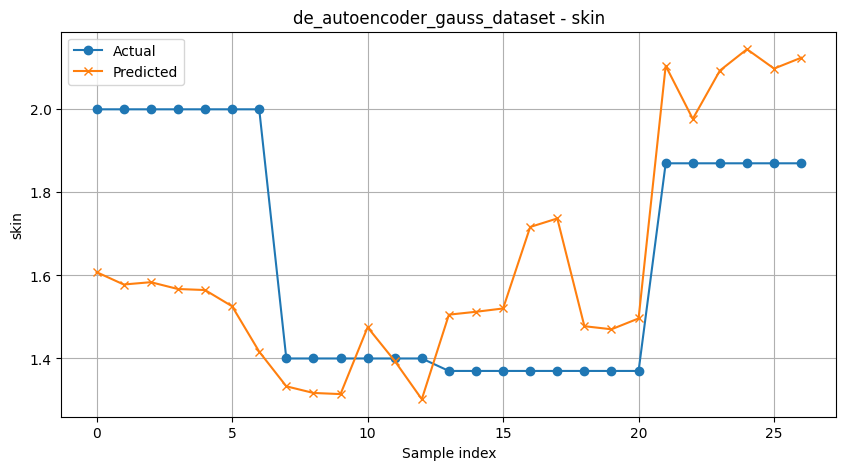

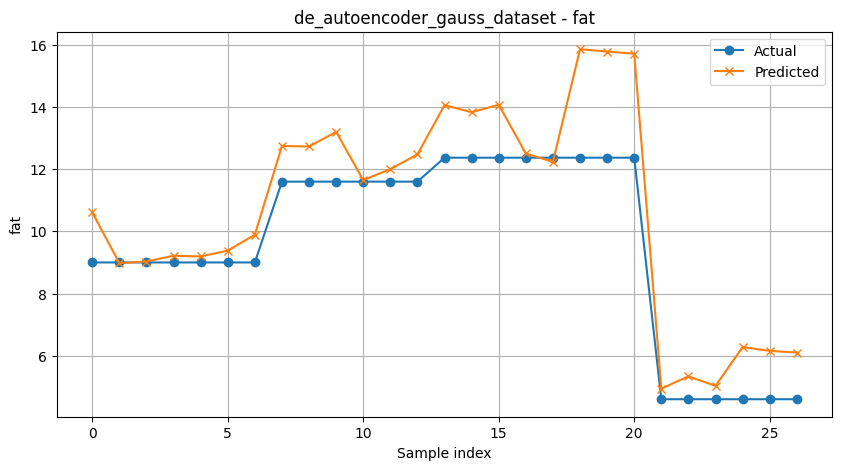

In [4]:
data_path = [#'/content/drive/MyDrive/Data/prepared data/autoencoder_dataset.csv',
            #  '/content/drive/MyDrive/Data/prepared data/de_autoencoder_comb_dataset.csv',
            #  '/content/drive/MyDrive/Data/prepared data/de_autoencoder_mask_dataset.csv',
             '/content/drive/MyDrive/Data/prepared data/de_autoencoder_gauss_dataset.csv']
result = [['dataset','layer','mae','r_square']]
for i in data_path:
  data = pd.read_csv(i)
  dataset = i.split('/')[-1].split('.')[0]

  # # Drop all rows for 'Volunteer_14'
  # data = data[data['volunteer'] != 'Volunteer_14']

  for layer in ['muscle','skin','fat']:

    # best_tuned_params = analyze_svr_tuned(data,layer)

    model, X_test, y_test, y_pred, mae, r2 = analyze(data,layer,None)
    # model, X_test, y_test, y_pred, mae, r2 = analyze(data,layer,best_tuned_params[1])


    plt.figure(figsize=(10,5))

    plt.plot(
        range(len(y_test)),
        y_test.values,
        marker='o',
        label='Actual'
        )

    plt.plot(
        range(len(y_pred)),
        y_pred,
        marker='x',
        label='Predicted'
        )

    plt.xlabel("Sample index")
    plt.ylabel(layer)
    plt.title(f"{dataset} - {layer}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # # model, X

    res = pd.concat([X_test, y_test.rename('y_test'), pd.Series(y_pred, index=X_test.index).rename('y_predicted')], axis=1)

    res.to_csv(f'/content/drive/MyDrive/Data/Result/result_{dataset}_{layer}.csv')
    result.append([dataset,layer,mae,r2])

In [5]:
df_result = pd.DataFrame(result[1:], columns=result[0])
# df_result.to_csv('/content/drive/MyDrive/Data/Result/result_new.csv')
df_result

,dataset,layer,mae,r_square
0,de_autoencoder_gauss_dataset,muscle,1.888116,-20.171501
1,de_autoencoder_gauss_dataset,skin,0.235915,0.002938
2,de_autoencoder_gauss_dataset,fat,1.117210,0.743590


Fitting 5 folds for each of 150 candidates, totalling 750 fits


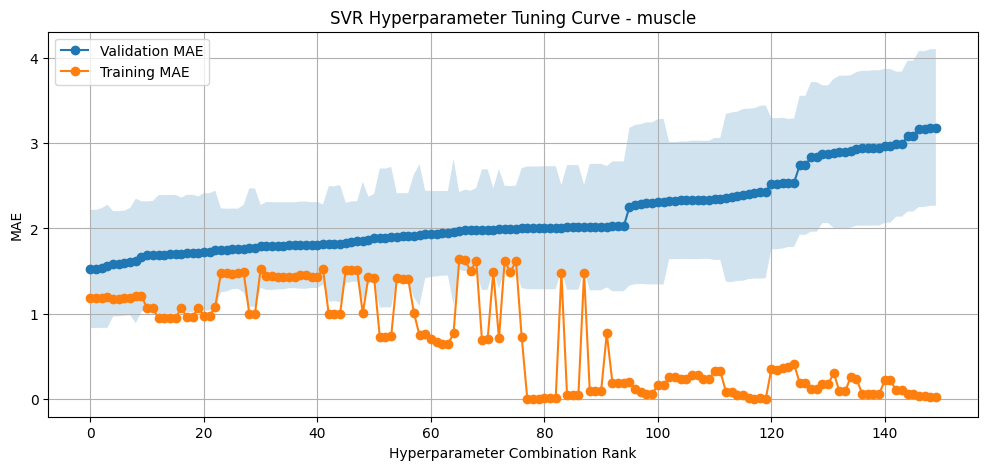

Best parameters: {'svr__C': 10, 'svr__epsilon': 0.01, 'svr__gamma': 0.001, 'svr__kernel': 'rbf'}
Best CV MAE: 1.5251857005630725
Test MAE: 1.4025636469184435
Test R2: -8.741762464657915


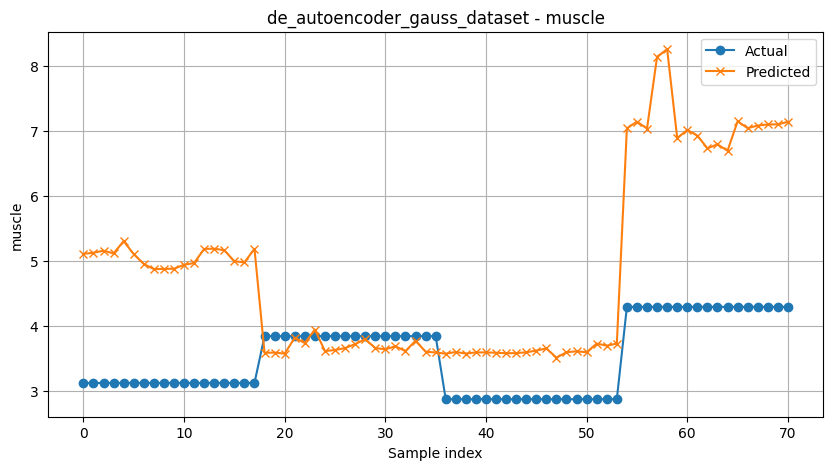

Fitting 5 folds for each of 150 candidates, totalling 750 fits


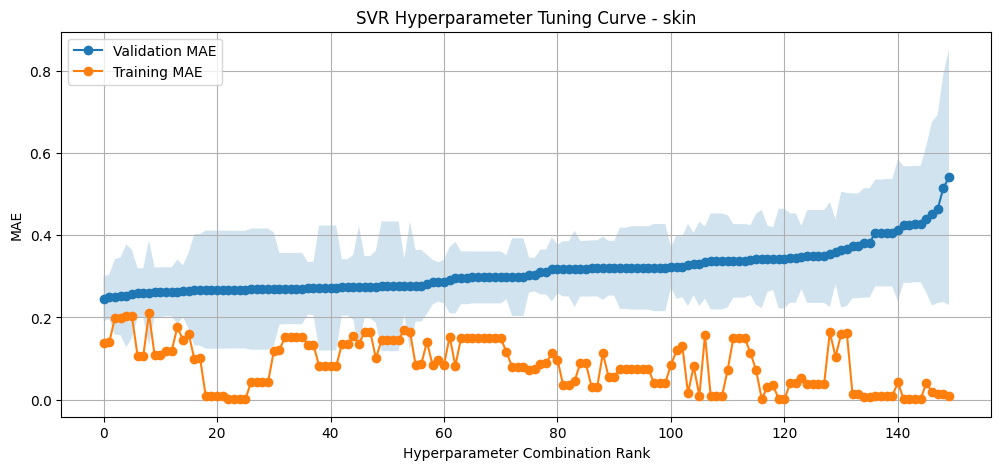

Best parameters: {'svr__C': 0.1, 'svr__epsilon': 0.001, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}
Best CV MAE: 0.245757402817669
Test MAE: 0.14890152545804725
Test R2: 0.6738680724087185


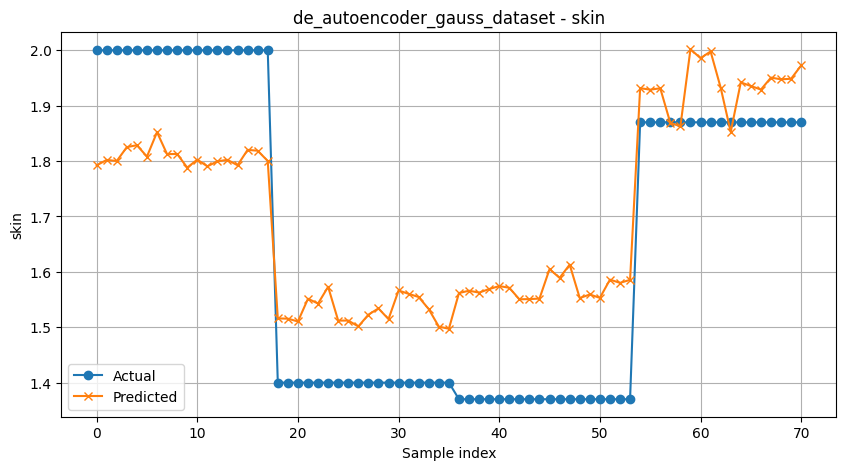

Fitting 5 folds for each of 150 candidates, totalling 750 fits


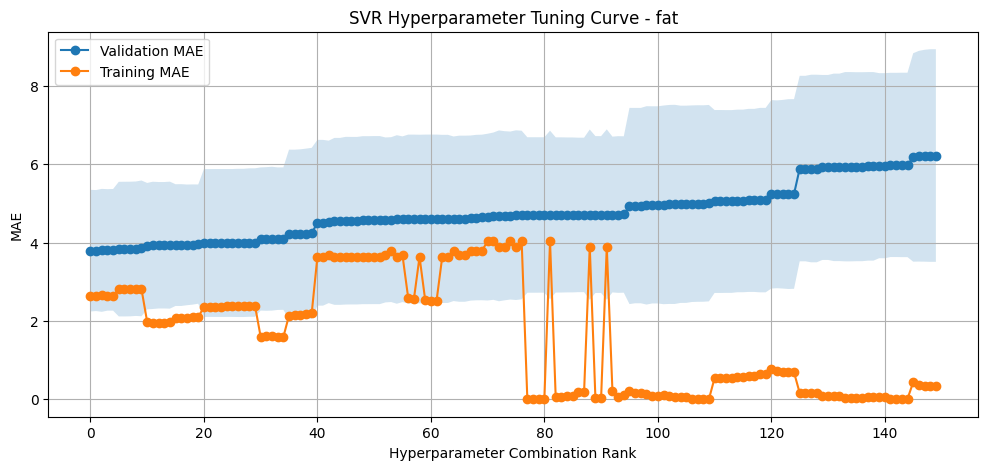

Best parameters: {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.001, 'svr__kernel': 'rbf'}
Best CV MAE: 3.79346865917102
Test MAE: 0.8528314322182707
Test R2: 0.8743603677001371


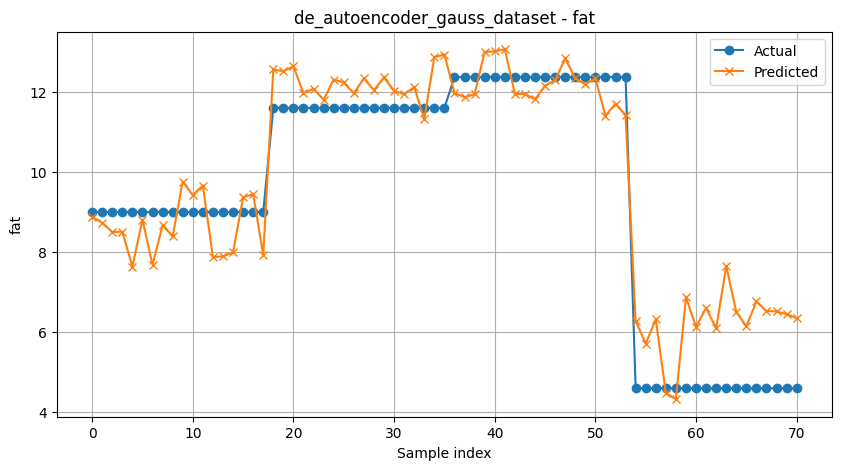

In [6]:
data_path = [#'/content/drive/MyDrive/Data/prepared data/autoencoder_dataset.csv',
            #  '/content/drive/MyDrive/Data/prepared data/de_autoencoder_comb_dataset.csv',
            #  '/content/drive/MyDrive/Data/prepared data/de_autoencoder_mask_dataset.csv',
             '/content/drive/MyDrive/Data/prepared data/de_autoencoder_gauss_dataset.csv']
result_2 = [['dataset','layer','mae','r_square']]
for i in data_path:
  data = pd.read_csv(i)
  dataset = i.split('/')[-1].split('.')[0]

  # # Drop all rows for 'Volunteer_14'
  # data = data[data['volunteer'] != 'Volunteer_14']

  for layer in ['muscle','skin','fat']:

    best_model, best_tuned_params, results, X_test, y_test, y_pred, mae, r2 = analyze_svr_tuned(data,layer)

    plt.figure(figsize=(10,5))

    plt.plot(
        range(len(y_test)),
        y_test.values,
        marker='o',
        label='Actual'
        )

    plt.plot(
        range(len(y_pred)),
        y_pred,
        marker='x',
        label='Predicted'
        )

    plt.xlabel("Sample index")
    plt.ylabel(layer)
    plt.title(f"{dataset} - {layer}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # # model, X_test, y_test, y_pred, mae, r2 = analyze(data,layer,None)
    # model, X_test, y_test, y_pred, mae, r2 = analyze(best_model,data,layer,best_tuned_params)
    result_2.append([dataset,layer,mae,r2])

In [7]:
df_result = pd.DataFrame(result_2[1:], columns=result_2[0])
# df_result.to_csv('/content/drive/MyDrive/Data/Result/result_new.csv')
df_result

,dataset,layer,mae,r_square
0,de_autoencoder_gauss_dataset,muscle,1.402564,-8.741762
1,de_autoencoder_gauss_dataset,skin,0.148902,0.673868
2,de_autoencoder_gauss_dataset,fat,0.852831,0.874360
